<a href="https://colab.research.google.com/github/EstevaoMO/machine-learning-aprendizadodemaquina/blob/main/02_dados_e_preprocessamento/colabs/Tratamento_de_Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tratamento de Outliers

## 1. Detecção e a Fronteira do IQR

Outliers são observações que **distorcem a variância natural da amostra**; e em modelos paramétricos como a Regressão Linear, um único valor extremo puxa a reta de predição para si, inflando desproporcionalmente métricas como RMSE.

O problema de usar a média para detectar outliers é circular, pois a média já foi corrompida pelo próprio outlier. A solução é o **Intervalo Interquartil (IQR)**, que mapeia o miolo central dos dados ignorando as caudas:

$$IQR = Q_3 - Q_1$$

A **cerca de Tukey** define formalmente os limites além dos quais um valor é discrepante:

$$\text{Limite inferior} = Q_1 - 1.5 \times IQR \qquad \text{Limite superior} = Q_3 + 1.5 \times IQR$$

> **Pressuposto importante:** a regra de Tukey foi desenhada para distribuições
> aproximadamente simétricas. Em distribuições com **skewness** elevado, ela tende a superestimar o número de outliers, sinalizando a cauda natural dos dados como anomalia. Sempre verifique a skewness antes de aplicar.
>
> **Entenda mais sobre skewness: [clique aqui](https://www.geeksforgeeks.org/data-science/skewness-measures-and-interpretation/)**.

Esses limites correspondem exatamente às **antenas (whiskers)** do boxplot.
Os pontos além delas são os outliers que o gráfico exibe explicitamente.

Usaremos o dataset `mpg`, com especificações técnicas de automóveis dos anos 70 e 80.
Nosso objetivo é prever a **eficiência de combustível (`mpg`)** a partir de potência (`horsepower`) e peso (`weight`).

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import RobustScaler

sns.set_theme(style='whitegrid', palette='muted')

df = sns.load_dataset('mpg').dropna()
X = df[['horsepower', 'weight']]
y = df['mpg']

print(f"\nSkewness das variáveis de interesse:")
print(df[['horsepower', 'weight', 'mpg']].skew().round(3))

print(f"\nShape: {df.shape}")
display(X.describe().round(2))


Skewness das variáveis de interesse:
horsepower    1.087
weight        0.520
mpg           0.457
dtype: float64

Shape: (392, 9)


,horsepower,weight
count,392.00,392.00
mean,104.47,2977.58
std,38.49,849.40
min,46.00,1613.00
25%,75.00,2225.25
50%,93.50,2803.50
75%,126.00,3614.75
max,230.00,5140.00


In [21]:
""" Cerca de Tukey e inspeção visual dos outliers """

Q1, Q3 = X['horsepower'].quantile([0.25, 0.75])
IQR      = Q3 - Q1
cerca_sup = Q3 + 1.5 * IQR

outliers    = df[X['horsepower'] > cerca_sup]
nao_outliers = df[X['horsepower'] <= cerca_sup]

print(f"Cerca superior: {cerca_sup:.1f} hp")
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)\n")
print(outliers[['name', 'model_year', 'cylinders', 'horsepower', 'mpg']].to_string(index=False))

Cerca superior: 202.5 hp
Outliers detectados: 10 (2.6%)

                        name  model_year  cylinders  horsepower  mpg
            chevrolet impala          70          8       220.0 14.0
           plymouth fury iii          70          8       215.0 14.0
            pontiac catalina          70          8       225.0 14.0
     buick estate wagon (sw)          70          8       225.0 14.0
                   ford f250          70          8       215.0 10.0
                  dodge d200          70          8       210.0 11.0
             mercury marquis          72          8       208.0 11.0
chrysler new yorker brougham          73          8       215.0 13.0
    buick electra 225 custom          73          8       225.0 12.0
          pontiac grand prix          73          8       230.0 16.0


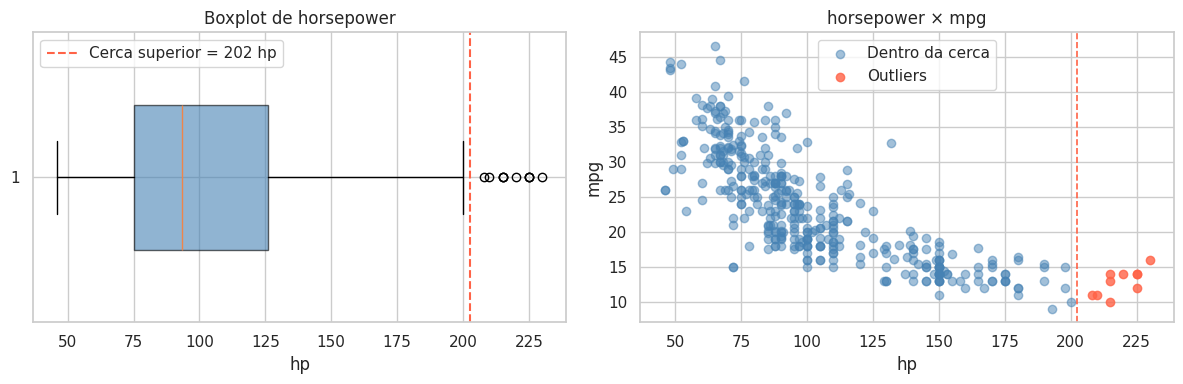

In [23]:
# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(X['horsepower'], vert=False, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].axvline(cerca_sup, color='tomato', linestyle='--', linewidth=1.5,
                label=f'Cerca superior = {cerca_sup:.0f} hp')
axes[0].set_title('Boxplot de horsepower')
axes[0].set_xlabel('hp')
axes[0].legend()

axes[1].scatter(nao_outliers['horsepower'], nao_outliers['mpg'],
                alpha=0.5, label='Dentro da cerca', color='steelblue')
axes[1].scatter(outliers['horsepower'], outliers['mpg'],
                alpha=0.8, label='Outliers', color='tomato', zorder=3)
axes[1].axvline(cerca_sup, color='tomato', linestyle='--', linewidth=1.2)
axes[1].set_title('horsepower × mpg')
axes[1].set_xlabel('hp'); axes[1].set_ylabel('mpg')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. O Problema da Remoção

A remoção automática de outliers é uma das decisões mais perigosas em pré-processamento.
Deletar linhas só é estatisticamente justificado quando há **comprovação de erro na coleta**. Por exemplo, um sensor com defeito ou um campo digitado incorretamente.

**Se estivéssemos modelando um sistema de detecção de fraudes em cartões de crédito, a transação milionária e completamente fora do padrão seria um erro para apagar ou seria exatamente o caso que a máquina deveria aprender a capturar?**

No nosso dataset, os carros de 230 hp existiram e circularam. Um modelo que nunca os viu no treino vai errar sistematicamente ao encontrá-los no mundo real.




## 3. Transformação Logarítmica e RobustScaler

Quando não podemos remover, **tratamos**. Duas técnicas complementares:

**Transformação logarítmica:** aplica $\ln(x+1)$ para comprimir caudas longas sem descartar nenhuma observação. A função preserva a ordem dos dados enquanto reduz a distância entre valores grandes, aproximando a distribuição da simetria.

**RobustScaler:** padroniza usando mediana e IQR em vez de média e desvio padrão, tornando o escalonamento imune aos próprios extremos que queremos tratar.

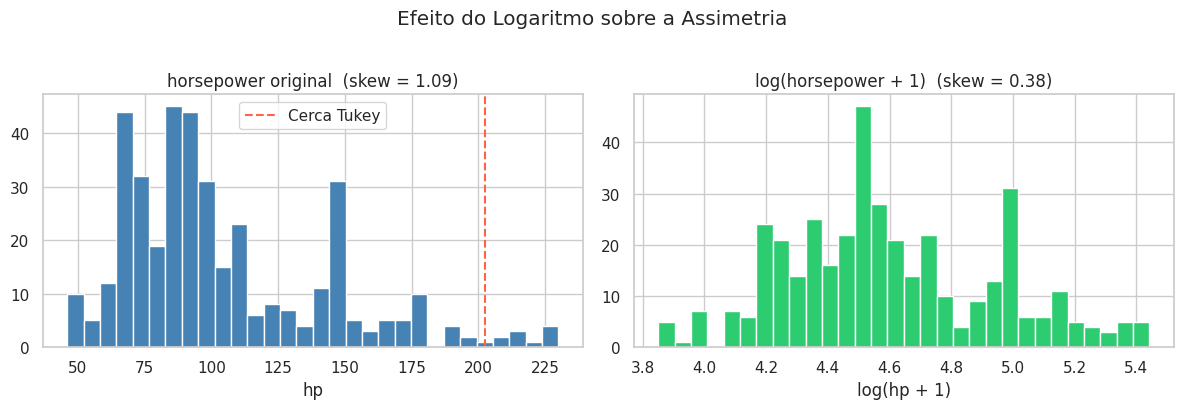

In [24]:
# Efeito da transformação logarítmica sobre horsepower
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X['horsepower'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(cerca_sup, color='tomato', linestyle='--', linewidth=1.5, label='Cerca Tukey')
axes[0].set_title(f'horsepower original  (skew = {X["horsepower"].skew():.2f})')
axes[0].set_xlabel('hp'); axes[0].legend()

axes[1].hist(np.log1p(X['horsepower']), bins=30, color='#2ecc71', edgecolor='white')
axes[1].set_title(f'log(horsepower + 1)  (skew = {np.log1p(X["horsepower"]).skew():.2f})')
axes[1].set_xlabel('log(hp + 1)')

plt.suptitle('Efeito do Logaritmo sobre a Assimetria', y=1.02)
plt.tight_layout()
plt.show()

> **Perceba como o conjunto de dados começa a se inclinar a uma distribuição normal (Gaussiana). Isso nos é favorável**

## 4. Testando Estratégias

Treinaremos três modelos de Regressão Linear avaliados no **mesmo conjunto de teste**.

| Modelo | Estratégia |
|---|---|
| **A** | Dados brutos, sem nenhum tratamento |
| **B** | Outliers removidos pelo IQR |
| **C** | Log + RobustScaler, sem remover |

O **RMSE** será nossa métrica principal. Por elevar o erro ao quadrado, penaliza
erros grandes de forma mais severa; exatamente onde outliers causam mais dano.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Caso A
modelo_A = LinearRegression().fit(X_train, y_train)

# Caso B
Q1_tr, Q3_tr = X_train['horsepower'].quantile([0.25, 0.75])
cerca_tr = Q3_tr + 1.5 * (Q3_tr - Q1_tr) #limiar
mask = X_train['horsepower'] <= cerca_tr #filtro
modelo_B = LinearRegression().fit(X_train[mask], y_train[mask])

# Caso C
sc = RobustScaler()
X_tr_c = sc.fit_transform(np.log1p(X_train))
X_te_c = sc.transform(np.log1p(X_test))
modelo_C = LinearRegression().fit(X_tr_c, np.log1p(y_train))
pred_C = np.expm1(modelo_C.predict(X_te_c))

resultados = {
    'A. Bruto':       [mean_absolute_error(y_test, modelo_A.predict(X_test)),
                        root_mean_squared_error(y_test, modelo_A.predict(X_test))],
    'B. Remoção IQR': [mean_absolute_error(y_test, modelo_B.predict(X_test)),
                        root_mean_squared_error(y_test, modelo_B.predict(X_test))],
    'C. Log+Robust':  [mean_absolute_error(y_test, pred_C),
                        root_mean_squared_error(y_test, pred_C)],
}

df_res = pd.DataFrame(resultados, index=['MAE', 'RMSE']).T.round(3)
display(df_res)

,MAE,RMSE
A. Bruto,3.506,4.218
B. Remoção IQR,3.558,4.273
C. Log+Robust,2.890,3.965
